# Steane Circ Level Noise (single round)

Data generation and analysis
+ different decoder: ML, MWPM
+ different observables: Z,X
+ different distances
+ different noise levels

analysis: 
+ show asymptotic behavior (not important)
+ determine thresholds


In [65]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import write_config, smart_read_folder
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

from tools.parameter import PATH_TO_CONFIG_FOLDER


## Config Defintions and Data Generation

Steane circ (order 0p) with only 1 QEC round (both log X and Z observable)

Circ noise with different noise levels

Decoding both in ML and MWPM


In [66]:
# General parameter
expected_p_th_log = -1.7
width = 0.5
noise_rates = [float(x) for x in np.logspace(expected_p_th_log - width , expected_p_th_log + width,dtype=float)]
distances = [3,5,7,9,11,13,15] # 3 is newly included not yet in data
qec_rounds = [1,]
order = "0p"
circuit_type = "steane"
noise_model_type = "circ"

# Main parameters
num_shots_ML = 1_000
decoder_type_ML = "ml"
# 30 min
# 700 min + for 100_000 data
num_shots_MWPM = 10_000
decoder_type_MWPM = "mwpm"

# Z config
observable_Z  = "Z"
init_state_Z = "0"
# X config
observable_X  = "X"
init_state_X = "p"

In [67]:
# Folder names (for writing data to file):
general_name = "md_1r_mp_CN"


In [68]:
# Switches for data generation
regen_data_everything = False 

regen_data_ML = False 
regen_data_MWPM = False 


In [69]:
# ML Config (Z)
# Verbose is better!
config_ML_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}
        
# write config to file
config_path = write_config(config_ML_Z, general_name, backup=True, sub_name="ML_Z")

# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [70]:
# ML Config (X)

config_ML_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
config_path = write_config(config_ML_X, general_name, backup=True, sub_name="ML_X")

# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [71]:
# MWPM Config (Z)

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
config_path = write_config(config_MWPM_Z, general_name, backup=True, sub_name="MWPM_Z")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [72]:
# MWPM Config (X)

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
config_path = write_config(config_MWPM_X, general_name, backup=True, sub_name="MWPM_X")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

# Analysis

In [73]:
# Folder paths (reading in data)
r_folder_path_ML_Z = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/ml/z/md_1r_mp_CN"
r_folder_path_ML_X = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/ml/x/md_1r_mp_CN"
r_folder_path_MWPM_Z = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/mwpm/z/md_1r_mp_CN"
r_folder_path_MWPM_X = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/mwpm/x/md_1r_mp_CN"


In [74]:
title_part_ml_z = "ML $Z$ obs."
filename_part_ml_z = "circ_ml_z" 

title_part_ml_x = "ML $X$ obs."
filename_part_ml_x = "circ_ml_x" 

title_part_mwpm_z = "MWPM $Z$ obs."
filename_part_mwpm_z = "circ_mwpm_z" 

title_part_mwpm_x = "MWPM $X$ obs."
filename_part_mwpm_x = "circ_mwpm_x" 

In [75]:
def analysis_pipeline(
        folder_path, 
        guess_pth, 
        guess_nu, 
        min_distance: list = None, 
        max_distance: list = None, 
        min_noise_rate: list = None,
        max_noise_rate: list = None,
        p_window: list = None,
        plots = True,
        title_part: str = "",
        filename_part: str = "",
        ):

    if p_window != None:
        if min_noise_rate != None or max_noise_rate != None:
            raise UserWarning("Both p_window and min-/max_noise_rate give! Too much restictions!")
        min_noise_rate = np.array(guess_pth) / p_window
        max_noise_rate = np.array(guess_pth) * p_window

    config, data = smart_read_folder(folder_path=folder_path)#folder_name=folder_name, basic_config=basic_config)
    print(f"Num_shots: {data["num_shots"]}")

    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        max_distance=max_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # complete
    if plots:
        if filename_part !="":
            filename_er_c = filename_part + "_log_error_rate_complete" 
            filename_fssa = filename_part + "_fssa" 
            filename_er_fssa = filename_part + "_log_error_rate_fssa" 
            filename_er_zoom = filename_part + "_log_error_rate_zoom" 
        else:
            filename_default = ""
            filename_er_c = filename_default 
            filename_fssa = filename_default 
            filename_er_fssa = filename_default 
            filename_er_zoom = filename_default 
        if title_part !="":
            title_er_c = title_part + ""
            title_fssa = title_part + ": Data collapse method"
            title_er_fssa = title_part + ": FSSA interval"
            title_er_zoom = title_part + ": Zoomed in"
        else:
            title_default = ""
            title_er_c = title_default
            title_fssa = title_default
            title_er_fssa = title_default
            title_er_zoom = title_default

        data_plot_log_error_rates(
            data,
            filename=filename_er_c,
            title=title_er_c,
            )
        data_plot_fssa_results(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            filename=filename_fssa,
            title=title_fssa,
            )
        # around threshold
        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            filename=filename_er_fssa,
            title=title_er_fssa,
        )
          
        idx = np.argmax(data["noise_rates"] > data["p_th"])
        idx_window = 3
        min_noise_rate_zoom =[data["noise_rates"][idx-idx_window] ]
        max_noise_rate_zoom =[data["noise_rates"][idx+idx_window] ]

        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate_zoom,
            max_noise_rate=max_noise_rate_zoom,
            filename=filename_er_zoom,
            title=title_er_zoom,
        )
    print(f"p_th: {data["p_th"]}")
    print(f"nu_fit: {data["nu_fit"]}")
    return data

### Generate analysis Data

In [76]:
# General fit parameters: 
g_pth_ml_Z = [0.028]
g_pth_ml_X = [0.035]
g_pth_mwpm_Z = [0.027]
g_pth_mwpm_X = [0.035]

g_nu = [1.5]

p_window = [10**(0.1)]
min_distance = [5]

Num_shots: 99000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.2028901864940624
             x: [ 2.933e-02  6.509e-01]
           nit: 52
          nfev: 99
 final_simplex: (array([[ 2.933e-02,  6.509e-01],
                       [ 2.933e-02,  6.509e-01],
                       [ 2.933e-02,  6.509e-01]]), array([ 1.203e+00,  1.203e+00,  1.203e+00]))
[0.02933236]
[0.0003042]


<Figure size 640x480 with 0 Axes>

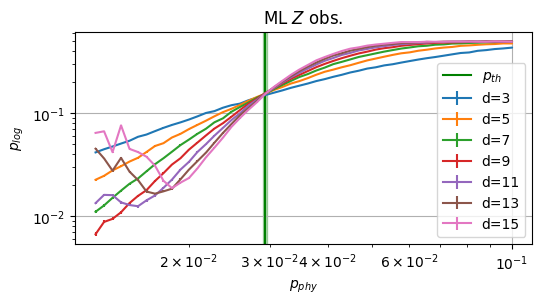

<Figure size 640x480 with 0 Axes>

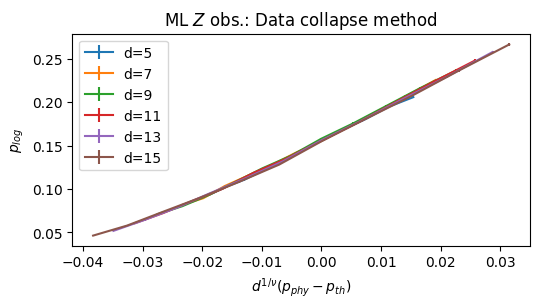

<Figure size 640x480 with 0 Axes>

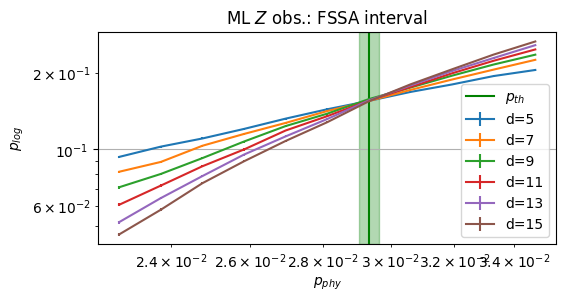

<Figure size 640x480 with 0 Axes>

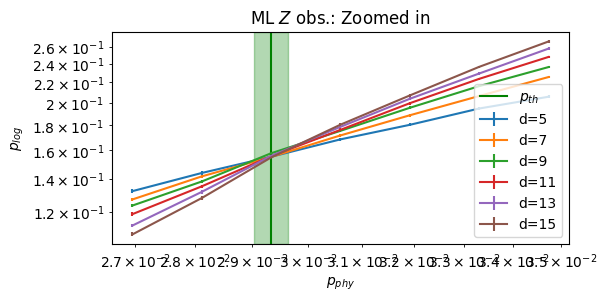

p_th: [0.02933236]
nu_fit: [1.53624563]


In [77]:
folder_path = r_folder_path_ML_Z
g_pth = g_pth_ml_Z

result = analysis_pipeline(
    folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window = p_window,
    filename_part = filename_part_ml_z,
    title_part =    title_part_ml_z,
    )

results_ML_Z = result

Num_shots: 100000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.5083889483151591
             x: [ 3.330e-02  7.087e-01]
           nit: 48
          nfev: 93
 final_simplex: (array([[ 3.330e-02,  7.087e-01],
                       [ 3.330e-02,  7.087e-01],
                       [ 3.330e-02,  7.087e-01]]), array([ 1.508e+00,  1.508e+00,  1.508e+00]))
[0.03330037]
[0.00025497]


<Figure size 640x480 with 0 Axes>

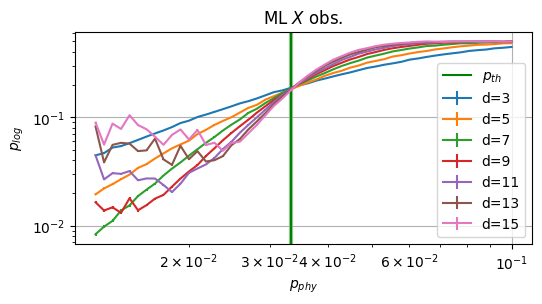

<Figure size 640x480 with 0 Axes>

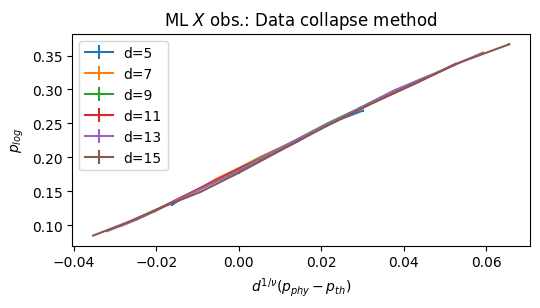

<Figure size 640x480 with 0 Axes>

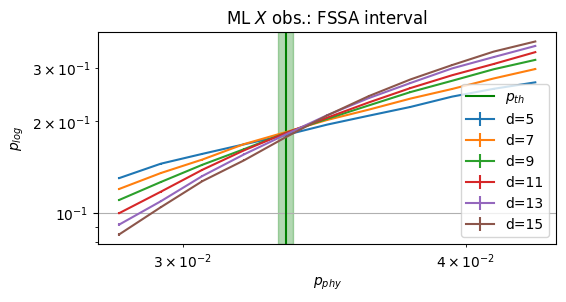

<Figure size 640x480 with 0 Axes>

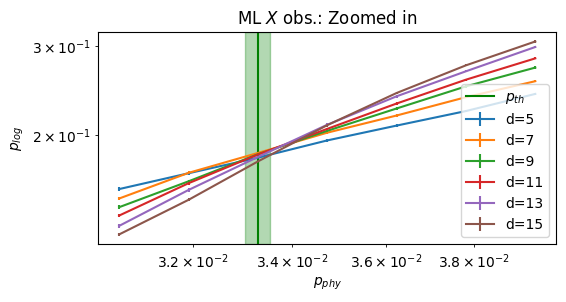

p_th: [0.03330037]
nu_fit: [1.41094001]


In [78]:
folder_path = r_folder_path_ML_X 
g_pth = g_pth_ml_X

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window = p_window,
    filename_part = filename_part_ml_x,
    title_part =    title_part_ml_x,
    )

results_ML_X = result

Num_shots: 100000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.2817873895841525
             x: [ 2.741e-02  6.843e-01]
           nit: 33
          nfev: 63
 final_simplex: (array([[ 2.741e-02,  6.843e-01],
                       [ 2.741e-02,  6.843e-01],
                       [ 2.741e-02,  6.843e-01]]), array([ 2.282e+00,  2.282e+00,  2.282e+00]))


[0.02741147]
[0.00025624]


<Figure size 640x480 with 0 Axes>

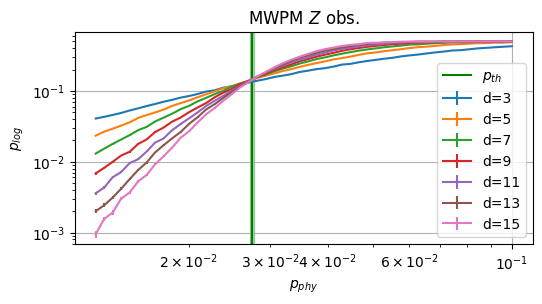

<Figure size 640x480 with 0 Axes>

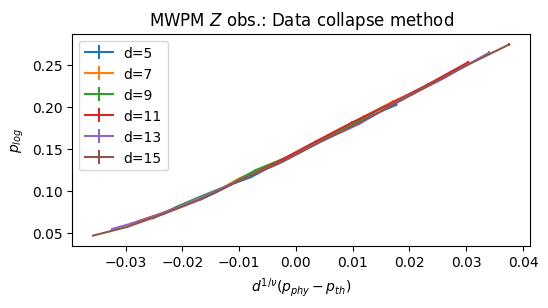

<Figure size 640x480 with 0 Axes>

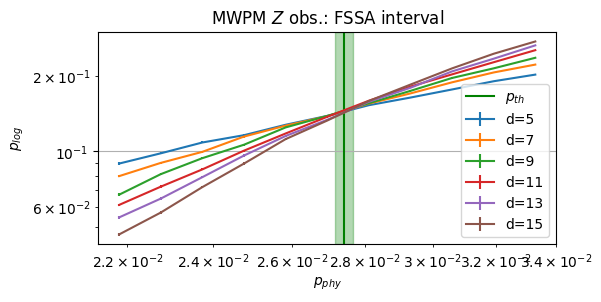

<Figure size 640x480 with 0 Axes>

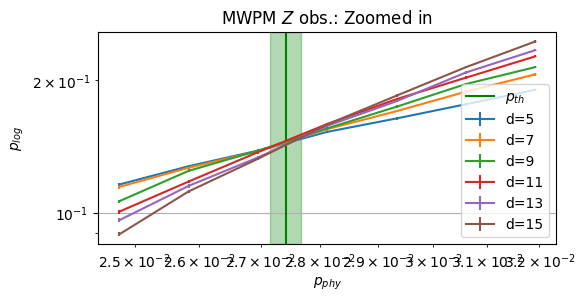

p_th: [0.02741147]
nu_fit: [1.46126241]


In [79]:
folder_path = r_folder_path_MWPM_Z 
g_pth = g_pth_mwpm_Z

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    filename_part = filename_part_mwpm_z,
    title_part =    title_part_mwpm_z,
    )

results_MWPM_Z= result

Num_shots: 100000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.9634369211485603
             x: [ 3.287e-02  7.411e-01]
           nit: 51
          nfev: 100
 final_simplex: (array([[ 3.287e-02,  7.411e-01],
                       [ 3.287e-02,  7.411e-01],
                       [ 3.287e-02,  7.411e-01]]), array([ 2.963e+00,  2.963e+00,  2.963e+00]))
[0.03286684]
[0.00033523]


<Figure size 640x480 with 0 Axes>

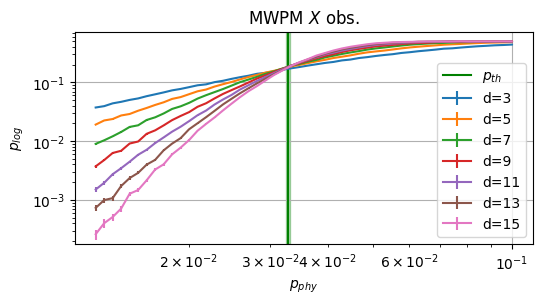

<Figure size 640x480 with 0 Axes>

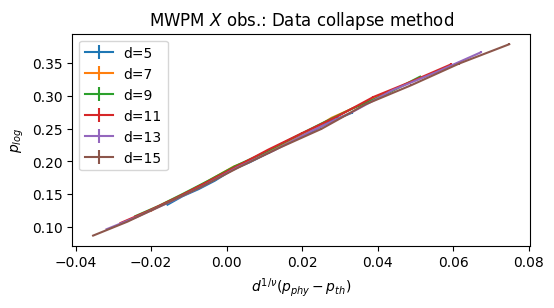

<Figure size 640x480 with 0 Axes>

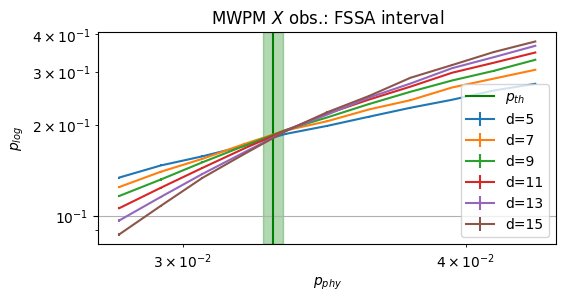

<Figure size 640x480 with 0 Axes>

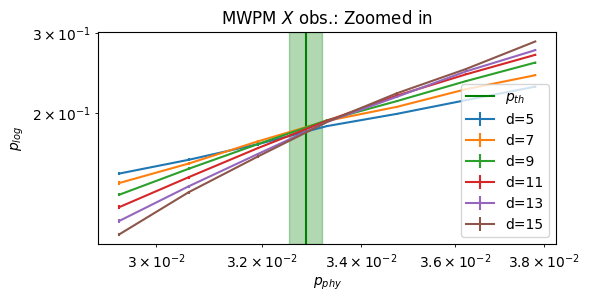

p_th: [0.03286684]
nu_fit: [1.34932785]


In [80]:
folder_path = r_folder_path_MWPM_X 
g_pth = g_pth_mwpm_X 

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    filename_part = filename_part_mwpm_x,
    title_part =    title_part_mwpm_x,
    )

results_MWPM_X = result

In [81]:
results = [results_ML_Z, results_ML_X, results_MWPM_Z, results_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]
for i in range(len(results)):
    print(f"{names[i]}: num_shots = {results[i]["num_shots"]/10**3}k")

ML Z: num_shots = 99.0k
ML X: num_shots = 100.0k
MWPM Z: num_shots = 100.0k
MWPM X: num_shots = 100.0k


## Thresholds Results (1 round circ noise)

In [82]:
# collection of all threshold:
results = [results_ML_Z, results_ML_X, results_MWPM_Z, results_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

for i in range(len(names)):
    print(f"For {names[i]}: threshold = {results[i]["p_th"][0]*10**2:.3f} +- {results[i]["err_p_th"][0]*10**2:.3f}") 



For ML Z: threshold = 2.933 +- 0.030
For ML X: threshold = 3.330 +- 0.025
For MWPM Z: threshold = 2.741 +- 0.026
For MWPM X: threshold = 3.287 +- 0.034


X error Threshold seems to be higher. 
Does this fit expectation? 

Z errors corrected first => more not tracked errors introduce by circ noise => residual error is higher => fits expectations.

## Varying parameters

In [83]:
# as collections
folder_names = [r_folder_path_ML_Z, r_folder_path_ML_X, r_folder_path_MWPM_Z, r_folder_path_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

g_pths = [g_pth_ml_Z, g_pth_ml_X, g_pth_mwpm_Z, g_pth_mwpm_X] 

g_nus = [g_nu] * 4

In [84]:
# Varying distanceif 
if False:
    min_distances = [5,7,9]
    n_distances = 3

    window_distance = 2 * n_distances  

    p_th_varied = np.zeros((len(min_distances), len(folder_names)))
    err_p_th_varied = np.zeros((len(min_distances), len(folder_names)))
    nu_fit_varied = np.zeros((len(min_distances), len(folder_names))) 
    for j in range(len(min_distances)):
        for i in range(len(folder_names)):
            result = analysis_pipeline(
                folder_path = folder_names[i],
                guess_pth = g_pths[i],
                guess_nu = g_nus[i],
                min_distance = [min_distances[j]], 
                max_distance = [min_distances[j] + window_distance],
                p_window= p_window,
                plots=False,
                )

            p_th_varied[j,i] =  result["p_th"][0]
            err_p_th_varied[j,i] =  result["err_p_th"][0]
            nu_fit_varied[j,i] = result["nu_fit"][0]

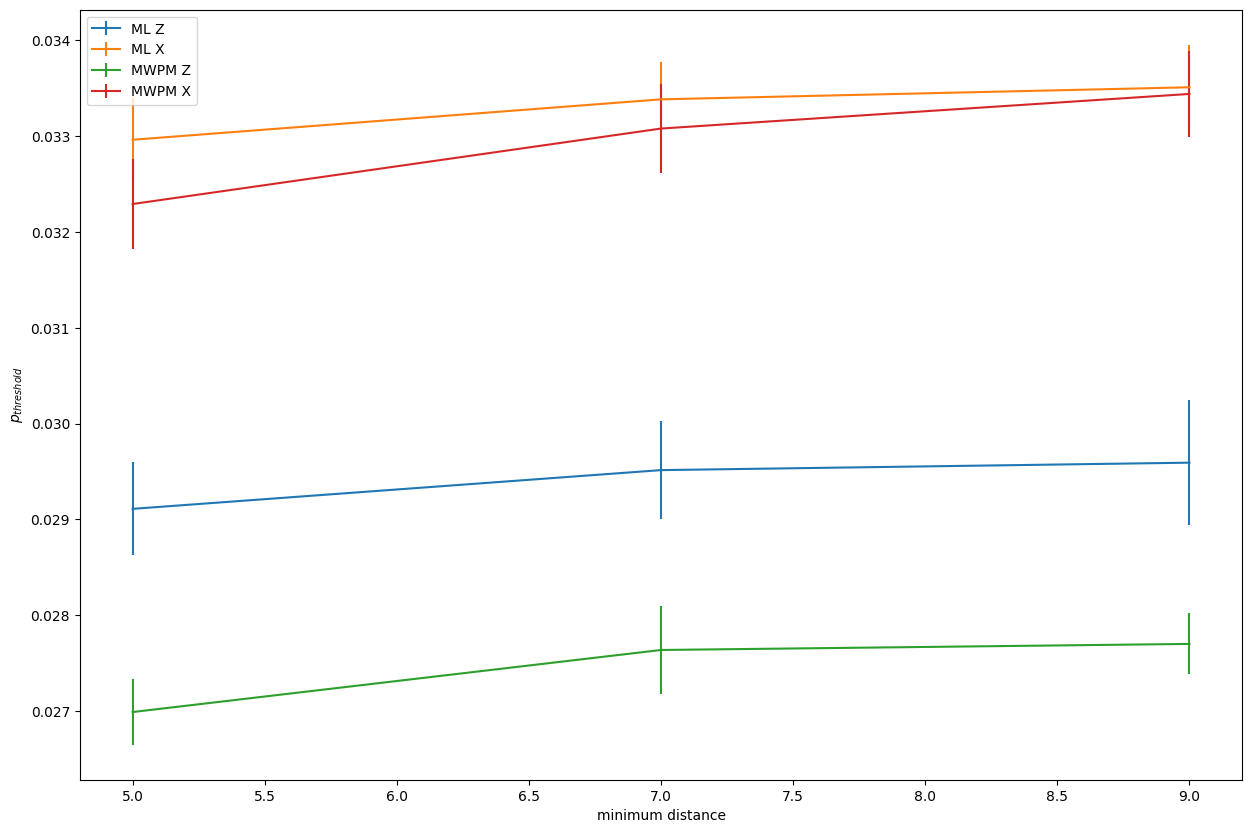

In [85]:
plt.figure(figsize=(15,10))
plt.xlabel("minimum distance")
for i in range(len(folder_names)):
    plt.errorbar(min_distances,p_th_varied[:,i], yerr=err_p_th_varied[:,i],label=names[i])
plt.ylabel("$p_{threshold}$")
# plt.yscale("log")
plt.legend()
plt.show()